# Generate Growth POD Components

This notebook fits the growth-field PCA/POD basis used by Model C's growth-feedback feature. **Inputs:** the displacement POD latents (`displacements.zarr`), per-element growth-stretch snapshots (`ip_growth_elem.zarr`), expander-volume snapshots (`expd_volumes.zarr`), and simulation metadata (`Design_and_Metadata.zarr`) produced by earlier steps in the FE-processing pipeline, plus the bundled mesh CSVs (`GOH_Nodes_Test_for_Visualization.csv`, `GOH_Elements_Test_for_Visualization.csv`). **Output:** a single `.npz` file (e.g. `growth_pca_trainonly_H60_W60_k8_val0.20_seed123.npz`) containing the fitted per-channel PCA bases, per-snapshot projected/normalized growth-PCA features, and the train/val simulation split -- consumed by Model C's training and evaluation scripts.

**Known provenance caveat:** the `N_COMPONENTS` parameter set in the PCA-config cell below currently reads `4`, which would regenerate a smaller `k4` basis if this notebook is re-run as-is. The `k8` (16-total-feature) artifact actually used throughout the reported results was produced by an earlier run of the same cell with `N_COMPONENTS = 8`; set it back to `8` before re-running if you want to reproduce that basis. See `data_processing/README.md` for the full explanation -- this does not affect any reported number, since every downstream script reads the already-saved `k8` file.

In [20]:
import zarr

ZARR_DISP  = "displacements.zarr"
ZARR_SDV   = "ip_growth_elem.zarr"               # lambda_g_x, lambda_g_y latents
ZARR_VOL   = "expd_volumes.zarr"
DESIGN_ZARR_PATH = "Design_and_Metadata.zarr"

U_LATENT_TEMPLATE = "latent_displ_r{r}/coeffs"

In [21]:
#Global Cache for the Coord and Connectivity CSVs
_BOTTOM_GRID_CACHE = None

def get_bottom_grid_cache():
    global _BOTTOM_GRID_CACHE
    if _BOTTOM_GRID_CACHE is None:
        H, W, bottom_idx, *_ = build_bottom_surface_elem_grid_mapping(
            nodes_csv="GOH_Nodes_Test_for_Visualization.csv",
            elems_csv="GOH_Elements_Test_for_Visualization.csv",
            tol_xy=1e-8,
        )
        _BOTTOM_GRID_CACHE = (H, W, bottom_idx)
    return _BOTTOM_GRID_CACHE


In [22]:
import numpy as np

def build_bottom_surface_elem_grid_mapping(
    nodes_csv: str = "GOH_Nodes_Test_for_Visualization.csv",
    elems_csv: str = "GOH_Elements_Test_for_Visualization.csv",
    tol_xy: float = 1e-8,
):
    """
    Build a structured (H,W) grid mapping for a two-layer quad mesh by selecting
    ONLY the bottom layer (smaller element centroid z) at each in-plane (x,y) cell.

    Assumed CSV formats (no headers):
      Nodes: [node_id, x, y, z]   (z required here)
      Elems: [elem_id, n1, n2, n3, n4]  (quads)

    Returns:
      H, W: inferred grid shape from unique centroid x/y positions
      bottom_elem_idx: (H*W,) element indices (0..Ne-1) selecting bottom element per cell
      cell_xy: (H*W, 2) centroid (x,y) per cell (for debugging)
      elem_id: (Ne,) element ids
      node_id: (Nn,) node ids
      node_xyz: (Nn,3)
      elem_conn_local: (Ne,4) node indices (0..Nn-1)
      xs, ys: grid lines (unique x and y centroid coords)
    """
    # ---- load nodes ----
    nodes = np.loadtxt(nodes_csv, delimiter=",", dtype=np.float64)
    if nodes.ndim != 2 or nodes.shape[1] < 4:
        raise ValueError(
            f"Nodes CSV must have 4 cols [id,x,y,z] (no headers). Got shape {nodes.shape}"
        )

    node_id = nodes[:, 0].astype(np.int64)
    node_xyz = nodes[:, 1:4].astype(np.float64)  # (Nn,3)

    node_id_to_local = {int(nid): i for i, nid in enumerate(node_id)}

    # ---- load elements ----
    elems = np.loadtxt(elems_csv, delimiter=",", dtype=np.int64)
    if elems.ndim != 2 or elems.shape[1] < 5:
        raise ValueError(
            f"Elements CSV must have >=5 cols [eid,n1,n2,n3,n4] (no headers). Got shape {elems.shape}"
        )

    elem_id = elems[:, 0].astype(np.int64)
    elem_conn_ids = elems[:, 1:5].astype(np.int64)  # (Ne,4)
    Ne = elem_conn_ids.shape[0]

    # Convert node IDs -> local node indices
    elem_conn_local = np.empty((Ne, 4), dtype=np.int64)
    for a in range(4):
        try:
            elem_conn_local[:, a] = np.array(
                [node_id_to_local[int(nid)] for nid in elem_conn_ids[:, a]],
                dtype=np.int64
            )
        except KeyError as e:
            raise KeyError(f"Element connectivity references node id not found: {e}")

    # ---- element centroids ----
    cent = node_xyz[elem_conn_local].mean(axis=1)  # (Ne,3)
    xe, ye, ze = cent[:, 0], cent[:, 1], cent[:, 2]

    # Quantize x,y to remove floating noise
    xe_q = np.round(xe / tol_xy) * tol_xy
    ye_q = np.round(ye / tol_xy) * tol_xy

    # Build grid lines
    xs = np.unique(xe_q); xs.sort()
    ys = np.unique(ye_q); ys.sort()
    W = xs.size
    H = ys.size
    n_cells = H * W

    ix = np.searchsorted(xs, xe_q)
    iy = np.searchsorted(ys, ye_q)
    cell = (iy * W + ix).astype(np.int64)  # (Ne,)

    # ---- select bottom element per cell (min z) ----
    bottom_elem_idx = np.full(n_cells, -1, dtype=np.int64)
    best_z = np.full(n_cells, np.inf, dtype=np.float64)

    for e in range(Ne):
        c = cell[e]
        if ze[e] < best_z[c]:
            best_z[c] = ze[e]
            bottom_elem_idx[c] = e

    occupied = bottom_elem_idx >= 0
    if not np.all(occupied):
        missing = np.where(~occupied)[0][:10]
        raise ValueError(
            f"Some grid cells have no assigned element (unexpected for structured mesh). "
            f"Example missing cell indices: {missing}"
        )

    # Debug: check it really reduced 2 layers -> 1 per cell
    # Count elements per cell (should be 2 for most cells in a 2-layer mesh)
    counts = np.bincount(cell, minlength=n_cells)
    print(f"[bottom mapping] Ne={Ne}, grid H={H}, W={W}, H*W={n_cells}")
    print(f"[bottom mapping] per-cell counts: min={counts[counts>0].min()}, max={counts.max()}, "
          f"unique occupied cells={np.count_nonzero(counts)}")
    print(f"[bottom mapping] selected bottom elems: {bottom_elem_idx.shape[0]} (should equal H*W)")

    # For debugging: centroid (x,y) per cell (from selected bottom element)
    cell_xy = np.stack([xe[bottom_elem_idx], ye[bottom_elem_idx]], axis=1)

    return H, W, bottom_elem_idx, cell_xy, elem_id, node_id, node_xyz, elem_conn_local, xs, ys


def rasterize_bottom_surface_field(
    vec_elem: np.ndarray,          # (Ne,)
    H: int, W: int,
    bottom_elem_idx: np.ndarray,   # (H*W,)
):
    """
    Convert an element field vector (Ne,) into a bottom-surface grid image (H,W)
    by selecting vec_elem at bottom_elem_idx for each cell.
    """
    flat = vec_elem[bottom_elem_idx]          # (H*W,)
    return flat.reshape(H, W)


In [23]:
def load_raw_data(r_modes: int):
    """
    Load raw data for a given r_modes (per field).
    Returns:
        U_lat        : (S, r)
        volume_snap  : (S,)   actual expander volume per snapshot
        G_field      : (S, 2, H, W) OR (S, 2, N)  (teacher-forced growth fields: x and y)
        sim_index    : (S,)
        time_vals    : (S,)
        volume_SP    : (S,)   volume setpoint per snapshot
        design_all   : (S, 7)
        n_sims       : int
    """
    from pathlib import Path

    g_disp   = zarr.open_group(ZARR_DISP, mode="r")
    g_design = zarr.open_group(DESIGN_ZARR_PATH, mode="r")
    g_sdv    = zarr.open_group(ZARR_SDV, mode="r")   # contains snaps_SDV1 and snaps_SDV4

    vol_root = Path(ZARR_VOL)

    u_path = U_LATENT_TEMPLATE.format(r=r_modes)
    U_lat = np.asarray(g_disp[u_path], dtype=np.float32).T  # (S, r)

    mgrp = g_design["Mapping_indexes_and_metadata"]
    sim_index = np.asarray(mgrp["sim_index"], dtype=np.int64)
    time_vals = np.asarray(mgrp["time_vals"], dtype=np.float64)

    volume_SP = np.asarray(
        zarr.open_array(str(vol_root / "volume_setpoint_per_snapshot"), mode="r"),
        dtype=np.float32
    )

    design_all = np.asarray(
        g_design["design_params_per_snapshot"], dtype=np.float32
    )

    S = U_lat.shape[0]
    assert sim_index.shape[0] == S == time_vals.shape[0]
    assert volume_SP.shape[0] == S == design_all.shape[0]

    volume_snap = np.asarray(
        zarr.open_array(str(vol_root / "expander_volume" / "cvol"), mode="r"),
        dtype=np.float32
    )
    if volume_snap.ndim != 1 or volume_snap.shape[0] != S:
        raise ValueError(f"Expected cvol as (S,) with S={S}, got shape {volume_snap.shape}")

    # -------- NEW: load growth fields (2 channels) and rasterize bottom surface --------
    def _load_snap_folder(folder_name: str) -> np.ndarray:
        candidates = [
            f"{folder_name}/{folder_name}",
            f"{folder_name}/data",
            f"{folder_name}/snaps",
            f"{folder_name}",
        ]
        last_err = None
        for key in candidates:
            try:
                return np.asarray(g_sdv[key], dtype=np.float32)
            except Exception as e:
                last_err = e
        raise KeyError(f"Could not load '{folder_name}'. Tried={candidates}. Last error={repr(last_err)}")

    Gx_raw = _load_snap_folder("snaps_SDV1")   # expected (Ne, S) = (7200, 42237)
    Gy_raw = _load_snap_folder("snaps_SDV4")   # expected (Ne, S)

    # Make snapshot-major: (S, Ne)
    if Gx_raw.shape == (7200, S):
        Gx = Gx_raw.T
    else:
        Gx = Gx_raw
    if Gy_raw.shape == (7200, S):
        Gy = Gy_raw.T
    else:
        Gy = Gy_raw

    if Gx.shape[0] != S or Gy.shape[0] != S:
        raise ValueError(f"Growth fields must be snapshot-aligned with S={S}. Got Gx={Gx.shape}, Gy={Gy.shape}")

    Ne = Gx.shape[1]
    if Ne != 7200:
        print(f"[warn] Expected Ne=7200 from mesh, got Ne={Ne}. Proceeding anyway.")

    # Bottom-surface element selection mapping -> 60x60 grid
    H, W, bottom_idx = get_bottom_grid_cache()
    assert H * W == bottom_idx.shape[0], (H, W, bottom_idx.shape)

    # Rasterize bottom surface: (S, H, W)
    # Vectorized gather: bottom_idx selects elements for each (i,j) cell
    Gx_bot = Gx[:, bottom_idx].reshape(S, H, W)
    Gy_bot = Gy[:, bottom_idx].reshape(S, H, W)

    # Stack channels: (S, 2, H, W)
    G_field = np.stack([Gx_bot, Gy_bot], axis=1).astype(np.float32)

    print(f"  G_field bottom: {G_field.shape}  (S,2,H,W) with H={H}, W={W}")
    # Quick sanity-check visualization: plot one rasterized growth-field snapshot (index k)
    # to confirm the bottom-surface rasterization looks reasonable before fitting PCA below.
    import matplotlib.pyplot as plt
    k = 1000
    plt.figure(); plt.imshow(G_field[k,0], origin="lower"); plt.title("Gx bottom"); plt.colorbar(); plt.show()
    plt.figure(); plt.imshow(G_field[k,1], origin="lower"); plt.title("Gy bottom"); plt.colorbar(); plt.show()

    # -------------------------------------------------------------------------------


    return (
        U_lat,
        volume_snap,
        G_field,
        sim_index,
        time_vals,
        volume_SP,
        design_all,
        len(np.unique(sim_index)),
    )


[bottom mapping] Ne=7200, grid H=60, W=60, H*W=3600
[bottom mapping] per-cell counts: min=2, max=2, unique occupied cells=3600
[bottom mapping] selected bottom elems: 3600 (should equal H*W)
  G_field bottom: (42237, 2, 60, 60)  (S,2,H,W) with H=60, W=60


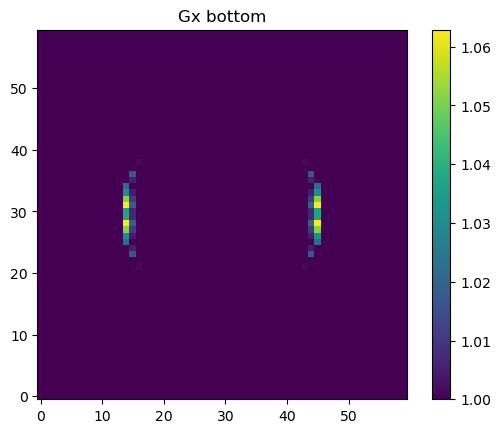

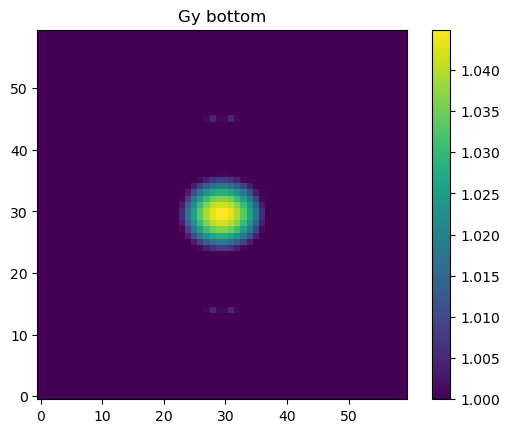

[data] S=42237, G_field=(42237, 2, 60, 60) -> per-channel vector length N=3600
[split] n_sims=927 | train_sims=742 | val_sims=185
[split] train snapshots=33992 | val snapshots=8245

Fitting PCA_x on TRAIN snapshots...
Fitting PCA_y on TRAIN snapshots...

[PCA] cumulative explained variance ratio (train fit):
  Gx: 0.9407
  Gy: 0.9819

Projecting ALL snapshots...
[proj] Xx_all=(42237, 4), Xy_all=(42237, 4)
[proj] X_pca_all=(42237, 8) (total growth dims = 8)
[pca-norm] mean/std computed on TRAIN snapshots only.
[pca-norm] X_pca_all_norm shape: (42237, 8)

Saved PCA bases + projections to:
  growth_pca_trainonly_H60_W60_k4_val0.20_seed123.npz


In [24]:
# ============================================================
# PCA notebook: train-only PCA bases for growth (x and y)
# Uses the SAME train/val split logic as your prepare_dataset()
# (val_fraction defaults to 0.2 unless you change it here)
# ============================================================

import numpy as np
from sklearn.decomposition import PCA

# -------------------------
# CONFIG (match training)
# -------------------------
R_MODES_FOR_ALIGNMENT = 9   # any r works as long as sim_index aligns to G_field
VAL_FRACTION = 0.2          # IMPORTANT: matches prepare_dataset default
SEED = 123                  # IMPORTANT: match your set_seed(SEED) usage / shuffle seed

# PCA config
# NOTE (provenance caveat -- see data_processing/README.md): the on-disk k8 growth-POD
# basis actually used throughout the reported pipeline (growth_pca_trainonly_H60_W60_k8_...npz)
# was produced by an earlier run of this cell with N_COMPONENTS = 8. The value saved below (4)
# would regenerate a smaller k4 basis (8 total features instead of 16) if this cell is re-run
# as-is. To reproduce the k8 basis used for the reported results, set N_COMPONENTS = 8 before
# running this notebook. This does not affect any reported number -- every downstream
# training/eval script reads the already-saved k8 .npz file, not a fresh re-run of this cell.
N_COMPONENTS = 4            # per-channel PCA comps; total features = 2*N_COMPONENTS when concatenated
SVD_SOLVER = "randomized"   # good for large matrices
PCA_RANDOM_STATE = 123      # PCA's internal randomness (independent of split seed)

# Output
OUT_PATH = None  # if None, auto-generate filename


# -------------------------
# 1) Load growth fields (already bottom rasterized) + metadata
# -------------------------
# Your load_raw_data returns:
# U_lat, volume_snap, G_field, sim_index, time_vals, volume_SP, design_all, n_sims
(U_lat,
 volume_snap,
 G_field,      # (S, 2, H, W)
 sim_index,
 time_vals,
 volume_SP,
 design_all,
 n_sims) = load_raw_data(R_MODES_FOR_ALIGNMENT)

S = sim_index.shape[0]
if G_field.shape[0] != S or G_field.shape[1] != 2:
    raise ValueError(f"Expected G_field as (S,2,H,W). Got {G_field.shape}, S={S}")

H, W = int(G_field.shape[2]), int(G_field.shape[3])
N = H * W
print(f"[data] S={S}, G_field={G_field.shape} -> per-channel vector length N={N}")

# Flatten per channel: (S, N)
Gx_all = G_field[:, 0, :, :].reshape(S, N).astype(np.float32)
Gy_all = G_field[:, 1, :, :].reshape(S, N).astype(np.float32)


# -------------------------
# 2) Reproduce train/val split EXACTLY like prepare_dataset()
# -------------------------
rng = np.random.RandomState(SEED)
unique_sims = np.unique(sim_index)
rng.shuffle(unique_sims)

n_val = max(1, int(VAL_FRACTION * len(unique_sims)))
val_sims   = unique_sims[:n_val]
train_sims = unique_sims[n_val:]
train_mask = np.isin(sim_index, train_sims)

print(f"[split] n_sims={len(unique_sims)} | train_sims={len(train_sims)} | val_sims={len(val_sims)}")
print(f"[split] train snapshots={int(train_mask.sum())} | val snapshots={int((~train_mask).sum())}")


# -------------------------
# 3) Fit PCA on TRAIN snapshots only (separately for x and y)
# -------------------------
pca_x = PCA(n_components=N_COMPONENTS, svd_solver=SVD_SOLVER, random_state=PCA_RANDOM_STATE)
pca_y = PCA(n_components=N_COMPONENTS, svd_solver=SVD_SOLVER, random_state=PCA_RANDOM_STATE)

print("\nFitting PCA_x on TRAIN snapshots...")
pca_x.fit(Gx_all[train_mask])

print("Fitting PCA_y on TRAIN snapshots...")
pca_y.fit(Gy_all[train_mask])

print("\n[PCA] cumulative explained variance ratio (train fit):")
print(f"  Gx: {float(np.sum(pca_x.explained_variance_ratio_)):.4f}")
print(f"  Gy: {float(np.sum(pca_y.explained_variance_ratio_)):.4f}")


# -------------------------
# 4) Project ALL snapshots using train-fitted bases
# -------------------------
print("\nProjecting ALL snapshots...")
Xx_all = pca_x.transform(Gx_all).astype(np.float32)  # (S, k)
Xy_all = pca_y.transform(Gy_all).astype(np.float32)  # (S, k)

# Concatenated PCA features per snapshot: (S, 2k)
X_pca_all = np.concatenate([Xx_all, Xy_all], axis=1).astype(np.float32)

print(f"[proj] Xx_all={Xx_all.shape}, Xy_all={Xy_all.shape}")
print(f"[proj] X_pca_all={X_pca_all.shape} (total growth dims = {2*N_COMPONENTS})")


# -------------------------
# 5) (Recommended) Standardize PCA coords using TRAIN stats only
#    This is optional but keeps feature scaling consistent with your other inputs.
# -------------------------
pca_mean = X_pca_all[train_mask].mean(axis=0, keepdims=True)
pca_std  = X_pca_all[train_mask].std(axis=0, keepdims=True) + 1e-8
X_pca_all_norm = ((X_pca_all - pca_mean) / pca_std).astype(np.float32)

print("[pca-norm] mean/std computed on TRAIN snapshots only.")
print(f"[pca-norm] X_pca_all_norm shape: {X_pca_all_norm.shape}")


# -------------------------
# 6) Save results
# -------------------------
if OUT_PATH is None:
    OUT_PATH = f"growth_pca_trainonly_H{H}_W{W}_k{N_COMPONENTS}_val{VAL_FRACTION:.2f}_seed{SEED}.npz"

np.savez_compressed(
    OUT_PATH,

    # bookkeeping
    H=H, W=W, N=N,
    SEED=SEED,
    VAL_FRACTION=VAL_FRACTION,
    train_sims=train_sims.astype(np.int64),
    val_sims=val_sims.astype(np.int64),

    # raw PCA coords per snapshot
    Xx_all=Xx_all,             # (S, k)
    Xy_all=Xy_all,             # (S, k)
    X_pca_all=X_pca_all,       # (S, 2k)

    # normalized PCA coords per snapshot (recommended to feed model)
    X_pca_all_norm=X_pca_all_norm,  # (S, 2k)
    pca_feat_mean=pca_mean.astype(np.float32),  # (1, 2k)
    pca_feat_std=pca_std.astype(np.float32),    # (1, 2k)

    # PCA params (x)
    mean_x=pca_x.mean_.astype(np.float32),                 # (N,)
    components_x=pca_x.components_.astype(np.float32),     # (k, N)
    explained_var_ratio_x=pca_x.explained_variance_ratio_.astype(np.float32),

    # PCA params (y)
    mean_y=pca_y.mean_.astype(np.float32),
    components_y=pca_y.components_.astype(np.float32),
    explained_var_ratio_y=pca_y.explained_variance_ratio_y.astype(np.float32)
    if hasattr(pca_y, "explained_variance_ratio_y") else pca_y.explained_variance_ratio_.astype(np.float32),
)

print(f"\nSaved PCA bases + projections to:\n  {OUT_PATH}")
